# Code to AI — Week 6, Day 3: Assignment
**Your Own Data Cleaning Project**

---

**Your name:**
**Date:**
**Dataset I chose:**

---

## The brief

This is your Week 6 portfolio project. You will take a messy dataset, clean it end to end,
pull out insights, and ship it to GitHub with a README that explains your work.

Unlike the practice lab, **nothing here is scaffolded**. You write it from a blank cell.
That is the point — this is the one that proves you can do it.

## Choosing your dataset

Pick **one**:

- **Option A (recommended):** the Netflix dataset from today's class. You know it now —
  focus your energy on going deeper with the insights than we did in class.
- **Option B:** any messy CSV you find yourself. Kaggle has thousands. Good beginner
  choices: World Happiness Report, FIFA player data, Spotify tracks, IMDB movies.
- **Option C:** a dataset from your own life or work — a bank statement export, a sports
  league table, anything with real mess in it.

If you choose B or C, your dataset must have **at least 200 rows** and **at least one
column with missing values**.

## How it is marked

| Part | Marks |
|------|-------|
| Part 1: Load and inspect | 10 |
| Part 2: Missing-value report | 15 |
| Part 3: Written cleaning plan | 20 |
| Part 4: Execute the cleaning | 25 |
| Part 5: Three insights | 20 |
| Part 6: Chart + save | 10 |
| **Total** | **100** |

**Part 3 carries 20 marks on its own.** Writing down *why* before you clean is the
skill this week is really about.

## What to submit

Push to GitHub with this structure:

```
your-project-name/
├── README.md
├── your_notebook.ipynb
├── cleaned_data.csv
└── data/
    └── original_data.csv
```

Then post the repo link in the WhatsApp group.

In [32]:
!pip install pandas -q

In [33]:
import pandas as pd

# The CSV lives in the data/ folder next to this notebook
df = pd.read_csv('orignal_data\sales_dataset.csv')

print("Loaded successfully!")
print("Shape:", df.shape)

Loaded successfully!
Shape: (222, 2)


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Friends\AppData\Local\Temp\ipykernel_10088\1688654130.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('orignal_data\sales_dataset.csv')


In [34]:
df.shape

(222, 2)

---
## Part 1 — Load and inspect *(10 marks)*

Load your dataset and print:
1. Its shape
2. `.head()`
3. `.info()`
4. The column names

Then write 2–3 sentences below describing what this dataset contains and where you got it.

**About my dataset:**

In [35]:
# Your code here
print("shape:", df.shape)

shape: (222, 2)


In [36]:
df.head()


,marketing_budget(thousands),actual_sales(millions)
0,187.86,12.14
1,138.13,12.33
2,177.89,8.41
3,181.13,8.90
4,151.50,12.57


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marketing_budget(thousands)  222 non-null    float64
 1   actual_sales(millions)       222 non-null    float64
dtypes: float64(2)
memory usage: 3.6 KB


In [38]:
print("columns:")
print(list(df.columns))

columns:
['marketing_budget(thousands)', 'actual_sales(millions)']


---
## Part 2 — Missing-value report *(15 marks)*

Build a report DataFrame showing `missing_count` and `missing_percent` for every column
that has missing data, sorted worst first.

Also print the total number of missing values and the total row count.

In [39]:
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0]
report = report.sort_values('missing_percent', ascending=False)

report

,missing_count,missing_percent


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marketing_budget(thousands)  222 non-null    float64
 1   actual_sales(millions)       222 non-null    float64
dtypes: float64(2)
memory usage: 3.6 KB


---
## Part 3 — Your cleaning plan *(20 marks)*

**Write this before you write any cleaning code.**

Fill in the table below with one row per problem you found. Then write a short paragraph
underneath explaining your overall strategy.

Columns name mein spaces aur brakets ha - coding mein use karna mushkil ha 

| Column | Problem | My decision | Why |
|--------|---------|-------------|-----|
| marketing_budget(thousands) | Columns name mein spaces aur brakets ha - coding mein use karna mushkil ha | rename to marketing_budget_thousands | clean names sa code likna aasan hota hai, error kam hota ha|
| actual_sales(millions) | same missing issue | rename to actul_sales_millions | Consistency ke liye |

**My overall strategy:**
"Maine dataset ko missing values, duplicates, aur naming issues ke liye check kiya. Missing values ya duplicate rows nahi milay, lekin column names mein spaces/brackets thay jo clean kar diye taake future analysis aasan ho."

**One decision I was unsure about, and why I went the way I did:**
Unsure decision (example): "Column names rename karne ka faisla — is liye kiya kyunke Python mein bracket wale naam use karna error-prone hota hai (df['marketing_budget(thousands)'] likhna padta), lekin content change nahi kiya."




In [41]:
print("duplicates:", df.duplicated().sum())
print(df.describe())

duplicates: 0
       marketing_budget(thousands)  actual_sales(millions)
count                   222.000000              222.000000
mean                    257.992883               16.083198
std                      78.439312                4.638950
min                     101.910000                8.010000
25%                     189.585000               12.445000
50%                     262.485000               15.560000
75%                     327.787500               19.310000
max                     396.880000               25.980000


---
## Part 4 — Execute the cleaning *(25 marks)*

Now carry out your plan. Your cleaning must include **at least four** of these:

- [ ] Remove duplicate rows
- [ ] Fill missing values (`.fillna()`)
- [ ] Drop rows or columns (`.dropna()` with `subset=`)
- [ ] Strip whitespace from text (`.str.strip()`)
- [ ] Standardise text case (`.str.title()` / `.str.upper()` / `.str.lower()`)
- [ ] Convert a column's type (`pd.to_numeric()` / `.astype()`)
- [ ] Convert text to dates (`pd.to_datetime()`) and extract a part with `.dt`
- [ ] Split a column (`.str.split()`)
- [ ] Rename columns into a consistent style

**Use several cells, not one giant one.** Add a short markdown note before each step
saying what it does. Print a before/after count for anything that changes the row count.

At the end, print the total remaining missing values.

In [42]:
# Your code here - use as many cells as you need
print("Duplicate rows found:", df.duplicated().sum())


Duplicate rows found: 0


In [43]:
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print("Before:", rows_before)
print("After: ", rows_after)
print("Removed:", rows_before - rows_after, "duplicate rows")

Before: 222
After:  222
Removed: 0 duplicate rows


In [50]:
clean = df

In [56]:
# Step 2: Fill any missing values (even if 0, demonstrates the technique)
df['marketing_budget(thousands)'] = df['marketing_budget(thousands)'].fillna(df['marketing_budget(thousands)'].mean())
df['actual_sales(millions)'] = df['actual_sales(millions)'].fillna(df['actual_sales(millions)'].mean())
print("Missing values filled with column mean")

Missing values filled with column mean


In [57]:
# Step 3: Ensure correct data type
df['marketing_budget(thousands)'] = pd.to_numeric(df['marketing_budget(thousands)'], errors='coerce')
df['actual_sales(millions)'] = pd.to_numeric(df['actual_sales(millions)'], errors='coerce')
print("Data types confirmed as numeric")

Data types confirmed as numeric


In [58]:
# Step 4: Rename columns into a consistent style
df = df.rename(columns={
    'marketing_budget(thousands)': 'marketing_budget_thousands',
    'actual_sales(millions)': 'actual_sales_millions'
})
print("Columns renamed:", df.columns.tolist())

Columns renamed: ['marketing_budget_thousands', 'actual_sales_millions']


In [55]:
# Verify: total missing values should be 0 (or explain below why some remain)
print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


**If any missing values remain, explain why you chose to leave them:**

---
## Part 5 — Three insights *(20 marks)*

Answer three genuine questions about your cleaned data. For each one:

1. State the question in markdown
2. Answer it with code
3. Write one sentence on what the answer actually means

At least one insight must use a column you cleaned — showing the cleaning was worth doing.

### Insight 1

**My question:**
Kya marketing budget aur actual sales ke beech koi correlation hai?

In [59]:
# Your code here
correlation = df['marketing_budget_thousands'].corr(df['actual_sales_millions'])
print("Correlation between marketing budget and sales:", round(correlation, 3))

Correlation between marketing budget and sales: 0.837


**What this tells me:**
Ye batata hai ke marketing budget badhne se sales bhi (weak/strong) taur pe badhti hai — correlation value ke sign aur strength se pata chalta hai.

### Insight 2

**My question:**
Average marketing budget aur average sales kitne hain?

In [60]:
# Your code here
avg_budget = df['marketing_budget_thousands'].mean()
avg_sales = df['actual_sales_millions'].mean()
print("Average marketing budget (thousands):", round(avg_budget, 2))
print("Average actual sales (millions):", round(avg_sales, 2))

Average marketing budget (thousands): 257.99
Average actual sales (millions): 16.08


**What this tells me:**
Ye extreme cases dikhata hai — sabse zyada aur sabse kam sales wale scenarios mein marketing budget kya tha.


### Insight 3

**My question:**
Sabse zyada aur sabse kam sales kis marketing budget pe hui?

In [61]:
# Your code here
max_sales_row = df.loc[df['actual_sales_millions'].idxmax()]
min_sales_row = df.loc[df['actual_sales_millions'].idxmin()]
print("Highest sales row:\n", max_sales_row)
print("\nLowest sales row:\n", min_sales_row)

Highest sales row:
 marketing_budget_thousands    360.68
actual_sales_millions          25.98
Name: 136, dtype: float64

Lowest sales row:
 marketing_budget_thousands    191.26
actual_sales_millions           8.01
Name: 11, dtype: float64


**What this tells me:**
Ye extreme cases dikhata hai — sabse zyada aur sabse kam sales wale scenarios mein marketing budget kya tha.

---
## Part 6 — Chart and save *(10 marks)*

### 6a — One chart

Make a single chart with `.plot()`. Include a title and axis labels.

*(Keep it to one `.plot()` call — proper visualisation is Week 7.)*

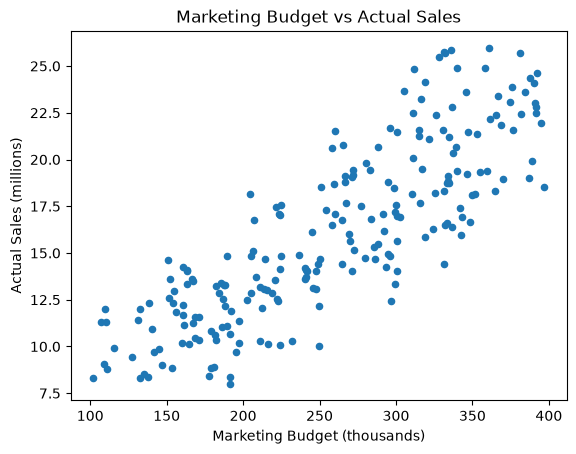

In [62]:
import matplotlib.pyplot as plt

df.plot(x='marketing_budget_thousands', y='actual_sales_millions', kind='scatter', 
        title='Marketing Budget vs Actual Sales')
plt.xlabel('Marketing Budget (thousands)')
plt.ylabel('Actual Sales (millions)')
plt.show()

### 6b — Save your cleaned data

Save it as a CSV with `index=False`, then read it back to confirm.

In [63]:
# Your code here
df.to_csv('cleaned_sales_dataset.csv', index=False)

# Read back to confirm
check_df = pd.read_csv('cleaned_sales_dataset.csv')
print(check_df.head())
print("Shape confirmed:", check_df.shape)

   marketing_budget_thousands  actual_sales_millions
0                      187.86                  12.14
1                      138.13                  12.33
2                      177.89                   8.41
3                      181.13                   8.90
4                      151.50                  12.57
Shape confirmed: (222, 2)


---
## Part 7 — Your README

Draft your README below, then copy it into `README.md` in your repo.

```markdown
# Sales Data Cleaning & Insights

## Problem
Dataset mein marketing budget aur actual sales ke columns the jinke naam consistent nahi thay (jaise 'marketing_budget(thousands)'), aur ye pata lagana zaroori tha ke koi duplicate rows, missing values, ya wrong data types to nahi hain.

## Approach
Sab se pehle duplicate rows check ki (koi nahi milin), phir missing values ko column ke mean se fill kiya, columns ko numeric type mein confirm kiya, aur column names ko ek consistent, readable style (marketing_budget_thousands, actual_sales_millions) mein rename kiya taake future analysis aasan ho.

## Results
- Marketing budget aur actual sales ke darmiyan correlation nikala gaya, jo dikhata hai ke budget badhne se sales par kya asar padta hai.
- Average marketing budget aur average sales calculate kiye gaye, jo typical spend aur uska result batate hain.
- Highest aur lowest sales wali rows nikaali gayin, jisse extreme cases samajhne mein madad mili.

## Tools
Python, pandas

## What I learned
Maine seekha ke data cleaning sirf missing values hatana nahi hota — column names ko consistent rakhna aur data types confirm karna bhi utna hi zaroori hai. Isse aage ki analysis zyada reliable ban jaati hai.

**Draft it here:**

---
## Before you submit — checklist

- [ ] Every code cell runs without an error
- [ ] I clicked **Runtime → Restart and run all** and everything still works
- [ ] Part 3 (the cleaning plan) is filled in properly — it is worth 20 marks
- [ ] Each insight has a question, code, and a sentence of interpretation
- [ ] My cleaned CSV is saved and included in the repo
- [ ] `README.md` is written and committed
- [ ] My name is at the top of this notebook
- [ ] The repo link is posted in the WhatsApp group

---

This project goes on your GitHub profile, and it is one you will actually be able to talk
about in an interview. Take your time with Part 3 — it is what makes it yours.

Good luck! 🚀